# Mental Health Outcome Prediction

**Goal:** Predict which factors are most likely to produce an *Improved* outcome using five ML models:
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Logistic Regression with L1 Regularization
- Support Vector Machine (SVM)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             ConfusionMatrixDisplay)

## 2. Load & Preview Data

In [2]:
df = pd.read_csv("data/mental_health.csv")
print(f"Dataset shape: {df.shape}")
print("\nOutcome distribution:")
print(df["Outcome"].value_counts())
print("\nClass balance (proportions):")
print(df["Outcome"].value_counts(normalize=True).round(3))
df.head()

Dataset shape: (500, 17)

Outcome distribution:
Outcome
Deteriorated    171
Improved        170
No Change       159
Name: count, dtype: int64

Class balance (proportions):
Outcome
Deteriorated    0.342
Improved        0.340
No Change       0.318
Name: proportion, dtype: float64


,Patient ID,Age,Gender,Diagnosis,Symptom Severity (1-10),Mood Score (1-10),Sleep Quality (1-10),Physical Activity (hrs/week),Medication,Therapy Type,Treatment Start Date,Treatment Duration (weeks),Stress Level (1-10),Outcome,Treatment Progress (1-10),AI-Detected Emotional State,Adherence to Treatment (%)
0,1,43,Female,Major Depressive Disorder,10,5,8,5,Mood Stabilizers,Interpersonal Therapy,2024-01-25,11,9,Deteriorated,7,Anxious,66
1,2,40,Female,Major Depressive Disorder,9,5,4,7,Antipsychotics,Interpersonal Therapy,2024-02-27,11,7,No Change,7,Neutral,78
2,3,55,Female,Major Depressive Disorder,6,3,4,3,SSRIs,Mindfulness-Based Therapy,2024-03-20,14,7,Deteriorated,5,Happy,62
3,4,34,Female,Major Depressive Disorder,6,3,6,5,SSRIs,Mindfulness-Based Therapy,2024-03-29,8,8,Deteriorated,10,Excited,72
4,5,52,Male,Panic Disorder,7,6,6,8,Anxiolytics,Interpersonal Therapy,2024-03-18,12,5,Deteriorated,6,Excited,63


## 3. Preprocessing

- Drop non-predictive columns (`Patient ID`, `Treatment Start Date`)
- Binary encode target: `Improved = 1`, everything else = `0`
- One-hot encode categorical features
- Train/test split (stratified)
- Scale features for KNN, Logistic Regression, and SVM

In [18]:
# Drop non-predictive columns
df = df.drop(columns=["Patient ID", "Treatment Start Date"])

# Binary encode target: Improved = 1, everything else = 0
df["Outcome"] = (df["Outcome"] == "Improved").astype(int)
print("Binary target distribution:")
print(df["Outcome"].value_counts())

# Separate features and target
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# One-hot encode categorical features
cat_cols = ["Gender", "Diagnosis", "Medication", "Therapy Type", "AI-Detected Emotional State"]
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)
print(f"\nFeature matrix shape after encoding: {X.shape}")
print(f"Features: {list(X.columns)}")

Binary target distribution:
Outcome
0    330
1    170
Name: count, dtype: int64

Feature matrix shape after encoding: (500, 31)
Features: ['Age', 'Symptom Severity (1-10)', 'Mood Score (1-10)', 'Sleep Quality (1-10)', 'Physical Activity (hrs/week)', 'Treatment Duration (weeks)', 'Stress Level (1-10)', 'Treatment Progress (1-10)', 'Adherence to Treatment (%)', 'Gender_Female', 'Gender_Male', 'Diagnosis_Bipolar Disorder', 'Diagnosis_Generalized Anxiety', 'Diagnosis_Major Depressive Disorder', 'Diagnosis_Panic Disorder', 'Medication_Antidepressants', 'Medication_Antipsychotics', 'Medication_Anxiolytics', 'Medication_Benzodiazepines', 'Medication_Mood Stabilizers', 'Medication_SSRIs', 'Therapy Type_Cognitive Behavioral Therapy', 'Therapy Type_Dialectical Behavioral Therapy', 'Therapy Type_Interpersonal Therapy', 'Therapy Type_Mindfulness-Based Therapy', 'AI-Detected Emotional State_Anxious', 'AI-Detected Emotional State_Depressed', 'AI-Detected Emotional State_Excited', 'AI-Detected Emotio

In [19]:
# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")

# Scale features (fit on train only, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

feature_names = X.columns.tolist()
print("Preprocessing complete.")

Training set size: 400
Test set size:     100
Preprocessing complete.


## 4. Train Models

### 4a. KNN — Find Best K via Cross-Validation

Best K = 1  (CV F1 = 0.338)


OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 128 or lower
OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 128 or lower


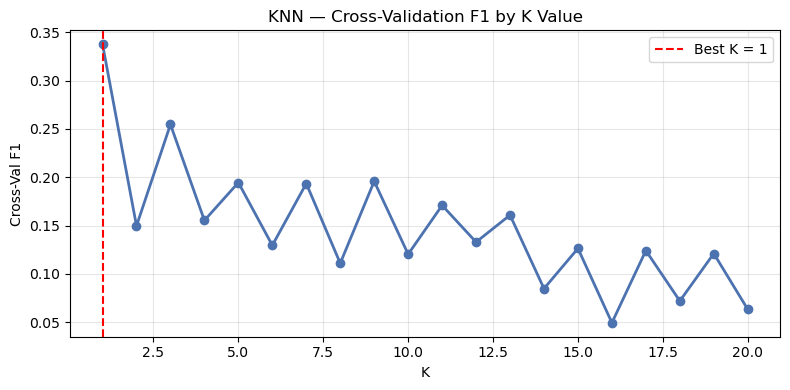

KNN trained.


In [20]:
k_range = range(1, 21)
k_scores = []
for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_train_scaled, y_train, cv=5, scoring="f1")
    k_scores.append(scores.mean())

best_k = list(k_range)[np.argmax(k_scores)]
print(f"Best K = {best_k}  (CV F1 = {max(k_scores):.3f})")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), k_scores, marker="o", color="#4C72B0", linewidth=2)
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.xlabel("K"); plt.ylabel("Cross-Val F1")
plt.title("KNN — Cross-Validation F1 by K Value")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
print("KNN trained.")

### 4b. Decision Tree

In [21]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
print("Decision Tree trained.")

Decision Tree trained.


### 4c. Random Forest

In [22]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


### 4d. Logistic Regression with L1 Regularization

In [23]:
lr = LogisticRegression(penalty="l1", solver="liblinear", C=1.0, random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
n_nonzero = np.sum(lr.coef_[0] != 0)
print(f"L1 selected {n_nonzero} / {len(feature_names)} features")
print(f"(Zeroed out {len(feature_names) - n_nonzero} features)")

L1 selected 27 / 31 features
(Zeroed out 4 features)


### 4e. Support Vector Machine

In [24]:
svm = SVC(kernel="rbf", C=1.0, probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
print("SVM trained.")

SVM trained.


## 5. Evaluate All Models

In [25]:
models = {
    "KNN":               (knn, X_test_scaled),
    "Decision Tree":     (dt,  X_test),
    "Random Forest":     (rf,  X_test),
    "Logistic Reg (L1)": (lr,  X_test_scaled),
    "SVM":               (svm, X_test_scaled),
}

results = []
for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
print("Model Comparison:")
results_df

Model Comparison:


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
KNN,0.54,0.312,0.294,0.303,0.480
Decision Tree,0.56,0.250,0.147,0.185,0.473
Random Forest,0.64,0.000,0.000,0.000,0.336
Logistic Reg (L1),0.68,1.000,0.059,0.111,0.529
SVM,0.65,0.000,0.000,0.000,0.553


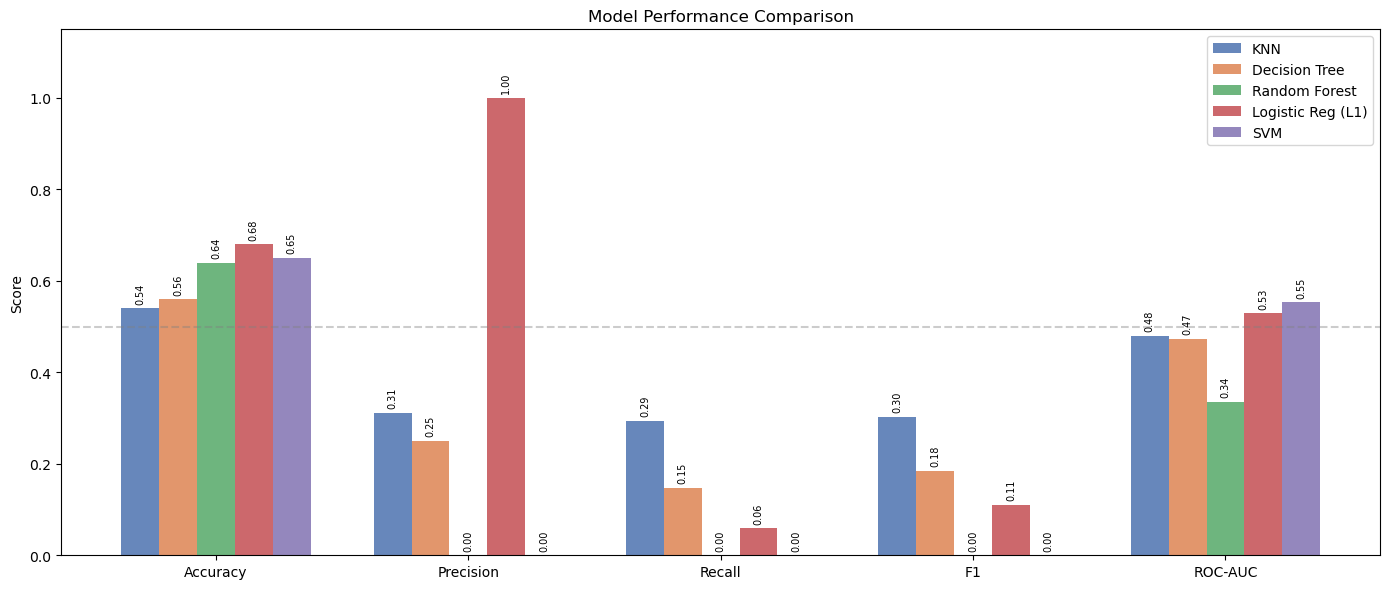

In [26]:
# Model comparison bar chart
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
x = np.arange(len(metrics))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model_name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i * width, row[metrics], width, label=model_name, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, row[metrics]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend(loc="upper right")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

Best Model by F1: KNN
F1 Score: 0.303
ROC-AUC:  0.480

Detailed Classification Report:
              precision    recall  f1-score   support

Not Improved       0.65      0.67      0.66        66
    Improved       0.31      0.29      0.30        34

    accuracy                           0.54       100
   macro avg       0.48      0.48      0.48       100
weighted avg       0.53      0.54      0.54       100



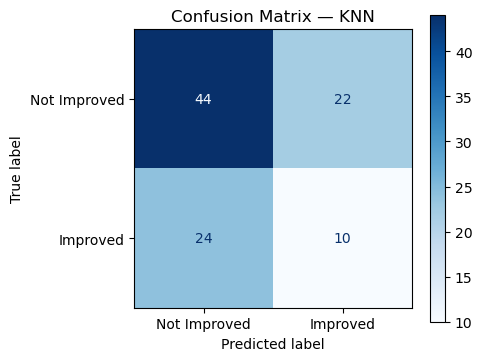

In [27]:
# Best model detailed report + confusion matrix
best_model_name = results_df["F1"].idxmax()
best_model, best_X = models[best_model_name]
y_pred_best = best_model.predict(best_X)

print(f"Best Model by F1: {best_model_name}")
# Fixed: Extract values first, then use in f-string to avoid bracket conflicts
f1_score = results_df.loc[best_model_name, "F1"]
roc_auc_score = results_df.loc[best_model_name, "ROC-AUC"]
print(f"F1 Score: {f1_score:.3f}")
print(f"ROC-AUC:  {roc_auc_score:.3f}")
print()
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=["Not Improved", "Improved"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=["Not Improved", "Improved"],
    cmap="Blues", ax=ax
)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout(); plt.show()

## 6. Feature Importance

### 6a. Random Forest

Top 10 features — Random Forest:
Age                              0.1089
Adherence to Treatment (%)       0.1017
Physical Activity (hrs/week)     0.0746
Treatment Duration (weeks)       0.0725
Mood Score (1-10)                0.0598
Treatment Progress (1-10)        0.0572
Sleep Quality (1-10)             0.0570
Symptom Severity (1-10)          0.0559
Stress Level (1-10)              0.0550
Diagnosis_Generalized Anxiety    0.0210


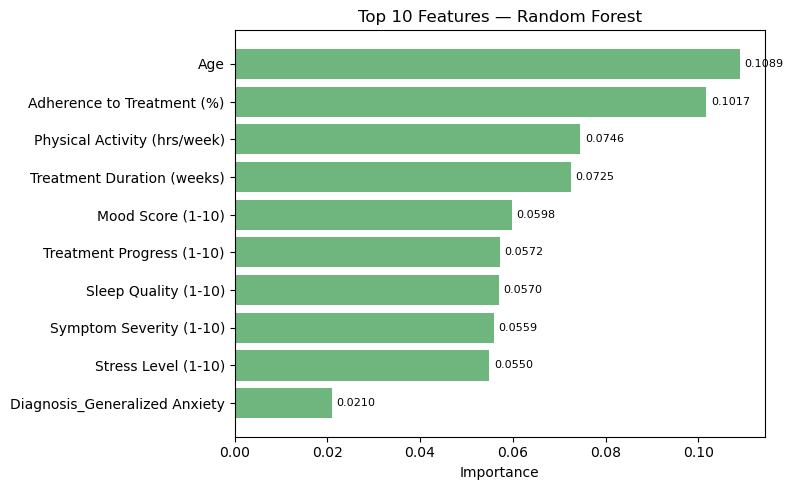

In [28]:
rf_importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top 10 features — Random Forest:")
print(rf_importances.head(10).round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
top_rf = rf_importances.head(10)
bars = ax.barh(top_rf.index[::-1], top_rf.values[::-1], color="#55A868", alpha=0.85)
for bar, val in zip(bars, top_rf.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8)
ax.set_xlabel("Importance")
ax.set_title("Top 10 Features — Random Forest")
plt.tight_layout(); plt.show()

### 6b. Decision Tree

In [29]:
dt_importances = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top 10 features — Decision Tree:")
print(dt_importances.head(10).round(4).to_string())

Top 10 features — Decision Tree:
Adherence to Treatment (%)                     0.1333
Therapy Type_Dialectical Behavioral Therapy    0.1292
Treatment Duration (weeks)                     0.1215
Mood Score (1-10)                              0.1039
Age                                            0.0952
Physical Activity (hrs/week)                   0.0703
Medication_SSRIs                               0.0698
Sleep Quality (1-10)                           0.0568
AI-Detected Emotional State_Neutral            0.0520
Diagnosis_Major Depressive Disorder            0.0439


### 6c. L1 Logistic Regression Coefficients

L1 selected 27 features:
Gender_Male                                  0.1903
Diagnosis_Major Depressive Disorder         -0.1520
AI-Detected Emotional State_Anxious         -0.1398
Adherence to Treatment (%)                  -0.1166
Treatment Progress (1-10)                    0.0739
Physical Activity (hrs/week)                 0.0694
Therapy Type_Cognitive Behavioral Therapy    0.0659
Mood Score (1-10)                           -0.0581
Medication_Benzodiazepines                  -0.0558
Diagnosis_Generalized Anxiety                0.0551
Medication_Mood Stabilizers                  0.0543
AI-Detected Emotional State_Neutral          0.0535
AI-Detected Emotional State_Depressed       -0.0494
Medication_SSRIs                             0.0473
Diagnosis_Panic Disorder                    -0.0450
Sleep Quality (1-10)                         0.0379
Stress Level (1-10)                          0.0353
Gender_Female                               -0.0284
Medication_Antidepressants             

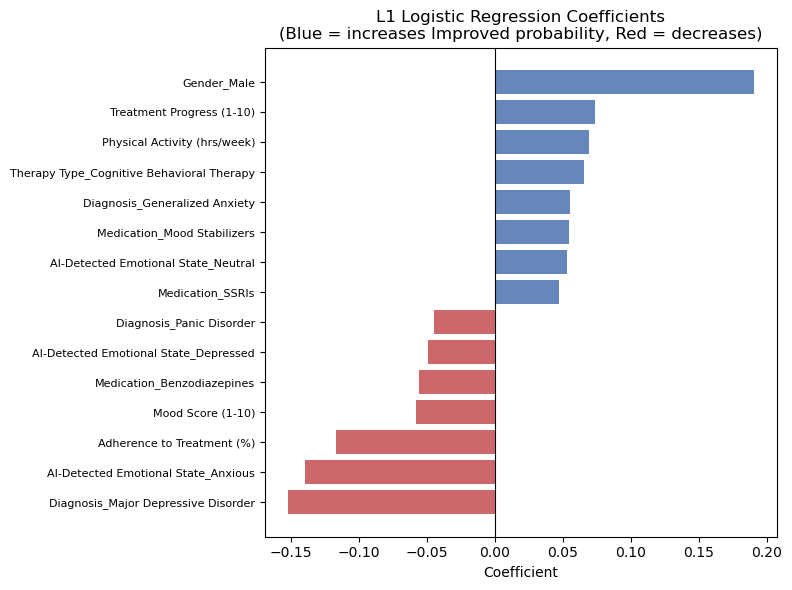

In [30]:
lr_coefs = pd.Series(lr.coef_[0], index=feature_names)
lr_nonzero = lr_coefs[lr_coefs != 0].sort_values(key=abs, ascending=False)
print(f"L1 selected {len(lr_nonzero)} features:")
print(lr_nonzero.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
lr_plot = lr_nonzero.head(15).sort_values()
bar_colors = ["#C44E52" if v < 0 else "#4C72B0" for v in lr_plot.values]
ax.barh(lr_plot.index, lr_plot.values, color=bar_colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient")
ax.set_title("L1 Logistic Regression Coefficients\n(Blue = increases Improved probability, Red = decreases)")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

## 7. Summary of Key Findings

In [32]:
print("=" * 55)
print("SUMMARY — KEY FACTORS FOR 'IMPROVED' OUTCOME")
print("=" * 55)

print(f"\nBest Model: {best_model_name}")
# Fixed: Changed inner double quotes to single quotes to avoid quote conflict
print(f"  F1 Score: {results_df.loc[best_model_name, 'F1']:.3f}")
print(f"  ROC-AUC:  {results_df.loc[best_model_name, 'ROC-AUC']:.3f}")

print("\nTop 5 predictive factors (Random Forest):")
for i, (feat, imp) in enumerate(rf_importances.head(5).items(), 1):
    print(f"  {i}. {feat}  (importance: {imp:.4f})")

print("\nFactors INCREASING Improved probability (L1 Logistic Regression):")
for feat, coef in lr_nonzero[lr_nonzero > 0].head(5).items():
    print(f"  + {feat}  (coef: {coef:.4f})")

print("\nFactors DECREASING Improved probability (L1 Logistic Regression):")
for feat, coef in lr_nonzero[lr_nonzero < 0].head(5).items():
    print(f"  - {feat}  (coef: {coef:.4f})")


SUMMARY — KEY FACTORS FOR 'IMPROVED' OUTCOME

Best Model: KNN
  F1 Score: 0.303
  ROC-AUC:  0.480

Top 5 predictive factors (Random Forest):
  1. Age  (importance: 0.1089)
  2. Adherence to Treatment (%)  (importance: 0.1017)
  3. Physical Activity (hrs/week)  (importance: 0.0746)
  4. Treatment Duration (weeks)  (importance: 0.0725)
  5. Mood Score (1-10)  (importance: 0.0598)

Factors INCREASING Improved probability (L1 Logistic Regression):
  + Gender_Male  (coef: 0.1903)
  + Treatment Progress (1-10)  (coef: 0.0739)
  + Physical Activity (hrs/week)  (coef: 0.0694)
  + Therapy Type_Cognitive Behavioral Therapy  (coef: 0.0659)
  + Diagnosis_Generalized Anxiety  (coef: 0.0551)

Factors DECREASING Improved probability (L1 Logistic Regression):
  - Diagnosis_Major Depressive Disorder  (coef: -0.1520)
  - AI-Detected Emotional State_Anxious  (coef: -0.1398)
  - Adherence to Treatment (%)  (coef: -0.1166)
  - Mood Score (1-10)  (coef: -0.0581)
  - Medication_Benzodiazepines  (coef: -0.055